# LQR + Kalman Observer — 3-State Coupled Bioreactor Model
**States:** `x = [VFA, EC, pH]`  
**Inputs:** `u = [u_urine, u_acetate]` (mL/step)  
**Measurements:** `y = [EC, pH]`

> H1 and H2 removed. A matrix uses identified EC/pH dynamics with physically motivated VFA coupling. B matrix assembled from two identification experiments — EC row from image 2 (dedicated EC step-response), pH row from image 1 (5-state identification). Units corrected to per (mL/s).

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.linalg import expm, solve_discrete_are

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print("✓ Libraries imported")

✓ Libraries imported


## 2. System Parameters

In [2]:
DT       = 5.0            # Sample time (seconds)
TANK_VOL = 875.0          # Tank volume (mL)
HRT      = 12 * 3600      # Hydraulic retention time (seconds)
tau_vfa  = 2.0 * 3600     # VFA time constant: 2 hours

print(f"Sample time : {DT} s")
print(f"Tank volume : {TANK_VOL} mL")
print(f"HRT         : {HRT/3600:.1f} h")
print(f"tau_VFA     : {tau_vfa/3600:.1f} h")

Sample time : 5.0 s
Tank volume : 875.0 mL
HRT         : 12.0 h
tau_VFA     : 2.0 h


## 3. A Matrix (Autonomous Dynamics)

EC and pH 2×2 block taken directly from identified A matrix (05/03/2026).  
H1 and H2 removed. VFA row and column added with physically motivated coupling.

| Term | Source |
|---|---|
| EC, pH 2×2 block | System identification (05/03/2026) |
| VFA self-decay | τ = 2h |
| VFA → EC | +15% of identified \|a_EC\| |
| VFA → pH | −8% of identified \|a_pH\| |
| EC → VFA | −3% of \|a_VFA\| (ionic inhibition) |
| pH → VFA | −5% of \|a_VFA\| (pH inhibits VFA removal) |

In [3]:
# Self-decay rate for VFA
a_vfa = -1/tau_vfa          # -1.389e-4 /s

# EC and pH terms — identified A matrix (05/03/2026), H1/H2 dropped
a_ec_ec =  -0.003140        # /s  τ = 4.7 min
a_ec_ph =   0.004951
a_ph_ec =   0.000225
a_ph_ph =  -0.000393        # /s  τ = 42.4 min

# VFA cross-coupling (physically motivated)
a_ec_vfa = -0.03 * abs(a_vfa)     # ionic inhibition
a_ph_vfa = -0.05 * abs(a_vfa)     # pH inhibits VFA removal
a_vfa_ec =  0.15 * abs(a_ec_ec)   # VFA raises EC
a_vfa_ph = -0.08 * abs(a_ph_ph)   # VFA lowers pH

# A_c: states = [VFA, EC, pH]
A_c = np.array([
    [a_vfa,     a_ec_vfa,  a_ph_vfa],   # VFA row
    [a_vfa_ec,  a_ec_ec,   a_ec_ph ],   # EC  row — identified
    [a_vfa_ph,  a_ph_ec,   a_ph_ph ],   # pH  row — identified
])

print("A_c (continuous, /s):")
print("         VFA            EC             pH")
for name, row in zip(['VFA','EC ','pH '], A_c):
    print(f"  {name}  " + "  ".join(f"{v:+.6e}" for v in row))

eigs_c = np.linalg.eigvals(A_c)
print("\nEigenvalues:")
for i, lam in enumerate(eigs_c):
    tau = -1/lam.real
    ts = f"{tau/60:.1f} min" if tau < 3600 else f"{tau/3600:.2f} h"
    print(f"  λ{i+1} = {lam.real:+.6e}  (τ ≈ {ts})")
print(f"\nDiagonal? {np.allclose(A_c, np.diag(np.diag(A_c)))}  — should be FALSE")
print(f"All stable? {np.all(eigs_c.real < 0)}")

A_c (continuous, /s):
         VFA            EC             pH
  VFA  -1.388889e-04  -4.166667e-06  -6.944444e-06
  EC   +4.710000e-04  -3.140000e-03  +4.951000e-03
  pH   -3.144000e-05  +2.250000e-04  -3.930000e-04

Eigenvalues:
  λ1 = -3.498179e-03  (τ ≈ 4.8 min)
  λ2 = -1.390864e-04  (τ ≈ 2.00 h)
  λ3 = -3.462336e-05  (τ ≈ 8.02 h)

Diagonal? False  — should be FALSE
All stable? True


## 4. B Matrix (Input Response)

Assembled from two identification experiments:
- **EC row** — from dedicated EC step-response experiment (image 2, 05/03/2026)
- **pH row** — from 5-state identification (image 1, 05/03/2026)

All values divided by DT=5s to convert from per-mL bolus to per (mL/s).

| Row | u_urine | u_acetate | Notes |
|---|---|---|---|
| VFA | 0.0 | +1.372e-4 | Urine fully fermented — no residual VFA load |
| EC  | +6.486e-4 | -1.612e-3 | Urine ion-rich → raises EC; acetate dilutes → drops |
| pH  | +4.980e-3 | -2.988e-3 | Urine raises pH; acetate lowers pH |

Phosphoric acid pump (Q_phosphoric) not included — not a controlled input.

In [4]:
# B_c: states = [VFA, EC, pH], inputs = [u_urine, u_acetate]
# Units: per (mL/s) — per-mL bolus values divided by DT=5s
#
# VFA: urine=0 (fully fermented), acetate=+0.000686/5
# EC:  urine=+0.003243/5 (image 2), acetate=-0.000060/5 (image 2)
# pH:  urine=+0.024900/5 (image 1), acetate=-0.014940/5 (image 1)
B_c = np.array([
    [ 0.0,             0.000686/DT ],   # VFA
    [ 0.003243/DT,    -0.000060/DT ],   # EC  — from image 2
    [ 0.024900/DT,    -0.014940/DT ],   # pH  — from image 1
])

C_c = np.array([
    [0, 1, 0],   # EC  measured
    [0, 0, 1],   # pH  measured
])

print("B_c (3×2) — per (mL/s):")
print("         u_urine       u_acetate")
for name, row in zip(['VFA','EC ','pH '], B_c):
    print(f"  {name}  {row[0]:+.5e}   {row[1]:+.5e}")
print("\nC_c:")
print(C_c)

B_c (3×2) — per (mL/s):
         u_urine       u_acetate
  VFA  +0.00000e+00   +1.37200e-04
  EC   +6.48600e-04   -1.20000e-05
  pH   +4.98000e-03   -2.98800e-03

C_c:
[[0 1 0]
 [0 0 1]]


## 5. Exact ZOH Discretisation

$$A_d = e^{A_c \Delta t}, \quad B_d = A_c^{-1}(A_d - I)\,B_c$$

In [5]:
A_d = expm(A_c * DT)
B_d = np.linalg.inv(A_c) @ (A_d - np.eye(3)) @ B_c
C_d = C_c.copy()

print("A_d (discrete ZOH, DT=5s):")
print("         VFA            EC             pH")
for name, row in zip(['VFA','EC ','pH '], A_d):
    print(f"  {name}  " + "  ".join(f"{v:+.8f}" for v in row))

print("\nB_d (discrete ZOH):")
print("         u_urine       u_acetate")
for name, row in zip(['VFA','EC ','pH '], B_d):
    print(f"  {name}  {row[0]:+.5e}   {row[1]:+.5e}")

eigs_d = np.linalg.eigvals(A_d)
print("\nDiscrete eigenvalues (|z| < 1 for stability):")
for i, z in enumerate(eigs_d):
    print(f"  z{i+1} = {z.real:.8f}   |z| = {abs(z):.8f}")

A_d (discrete ZOH, DT=5s):
         VFA            EC             pH
  VFA  +0.99930577  -0.00002068  -0.00003493
  EC   +0.00233387  +0.98443635  +0.02453758
  pH   -0.00015568  +0.00111512  +0.99805077

B_d (discrete ZOH):
         u_urine       u_acetate
  VFA  -4.67659e-07   +6.86023e-04
  EC   +3.52408e-03   -2.42564e-04
  pH   +2.48775e-02   -1.49255e-02

Discrete eigenvalues (|z| < 1 for stability):
  z1 = 0.98266118   |z| = 0.98266118
  z2 = 0.99930481   |z| = 0.99930481
  z3 = 0.99982690   |z| = 0.99982690


## 6. Nominal Operating Point & Affine Offset

In [6]:
x_nom      = np.array([50.05, 11.1219, 8.8037])
Q_baseline = TANK_VOL / HRT * DT
u_baseline = np.array([Q_baseline/2, Q_baseline/2])
d = (np.eye(3) - A_d) @ x_nom - B_d @ u_baseline

print(f"Nominal state:  VFA={x_nom[0]:.4f} mg/L  EC={x_nom[1]:.4f} mS/cm  pH={x_nom[2]:.4f}")
print(f"Baseline u:     urine={u_baseline[0]:.6f} mL/step  acetate={u_baseline[1]:.6f} mL/step")
print(f"Affine offset d: {d}")

err = np.linalg.norm(A_d @ x_nom + B_d @ u_baseline + d - x_nom)
print(f"Equilibrium check: {err:.2e}  ({'✓ OK' if err < 1e-10 else '✗ FAIL'})")

Nominal state:  VFA=50.0500 mg/L  EC=11.1219 mS/cm  pH=8.8037
Baseline u:     urine=0.050637 mL/step  acetate=0.050637 mL/step
Affine offset d: [ 0.03524882 -0.15990065  0.0120458 ]
Equilibrium check: 0.00e+00  (✓ OK)


## 7. LQR Controller Design

In [7]:
Q_ctrl = np.diag([100.0, 100.0, 100.0])
R_ctrl = np.diag([0.01,  0.01])

P_ctrl = solve_discrete_are(A_d, B_d, Q_ctrl, R_ctrl)
K = np.linalg.inv(R_ctrl + B_d.T @ P_ctrl @ B_d) @ (B_d.T @ P_ctrl @ A_d)

print("LQR gain K (2×3):")
print("         VFA          EC           pH")
for name, row in zip(['u_urine','u_acet '], K):
    print(f"  {name}  " + "  ".join(f"{v:+.5f}" for v in row))

A_cl = A_d - B_d @ K
eigs_cl = np.linalg.eigvals(A_cl)
print("\nClosed-loop poles:")
for i, z in enumerate(eigs_cl):
    print(f"  z{i+1} = {z.real:.8f}   |z| = {abs(z):.8f}")
print(f"All stable? {np.all(np.abs(eigs_cl) < 1)}")

LQR gain K (2×3):
         VFA          EC           pH
  u_urine  +22.74667  +42.30794  +23.50456
  u_acet   +68.17746  +49.98989  -19.20145

Closed-loop poles:
  z1 = 0.09601617   |z| = 0.09601617
  z2 = 0.98994606   |z| = 0.98994606
  z3 = 0.84077394   |z| = 0.84077394
All stable? True


## 8. Kalman Observer Design

With coupled A matrix, `L[VFA,:]` is non-zero — observer infers VFA from EC and pH measurements.

In [8]:
Q_obs = np.diag([1e-4, 1e-4, 1e-4])
R_obs = np.diag([1e-2, 1e-2])

P_obs = solve_discrete_are(A_d.T, C_d.T, Q_obs, R_obs)
L = P_obs @ C_d.T @ np.linalg.inv(C_d @ P_obs @ C_d.T + R_obs)

print("Kalman gain L (3×2):")
print("         y_EC         y_pH")
for name, row in zip(['VFA','EC ','pH '], L):
    print(f"  {name}  {row[0]:+.6f}   {row[1]:+.6f}")
print(f"\nL[VFA,:] = {L[0,:]}  (non-zero — observer corrects VFA from measurements)")

A_obs = A_d - L @ C_d
eigs_obs = np.linalg.eigvals(A_obs)
print("\nObserver poles:")
for i, z in enumerate(eigs_obs):
    print(f"  z{i+1} = {z.real:.8f}   |z| = {abs(z):.8f}")
print(f"All stable? {np.all(np.abs(eigs_obs) < 1)}")

Kalman gain L (3×2):
         y_EC         y_pH
  VFA  +0.069052   -0.012473
  EC   +0.086008   +0.010409
  pH   +0.010409   +0.092932

L[VFA,:] = [ 0.0690515 -0.0124727]  (non-zero — observer corrects VFA from measurements)

Observer poles:
  z1 = 0.99767103   |z| = 0.99767103
  z2 = 0.90259090   |z| = 0.90266060
  z3 = 0.90259090   |z| = 0.90266060
All stable? True


## 9. Simulation Setup

In [9]:
T_sim     = 10 * 3600
N         = int(T_sim / DT)
t_perturb = int(30 * 60 / DT)
t_hours   = np.arange(N) * DT / 3600

# Setpoints and initial state — start at nominal
x_sp    = np.array([50.05, 11.1219, 8.8037])
x_start = x_sp.copy()

# Pump bounds — single total flow constraint
TOTAL_LB = 0.025318 + 0.025318   # mL/step total (HRT=12h lower bound)
TOTAL_UB = 3.65     + 3.65         # mL/step total (0.730 mL/s per pump upper bound)
U_LB = np.array([TOTAL_LB/2, TOTAL_LB/2])
U_UB = np.array([TOTAL_UB/2, TOTAL_UB/2])

print(f"Simulation: {T_sim/3600:.0f} hours, {N} steps")
print(f"Perturbation: pH −0.5 at t = {t_perturb*DT/60:.0f} min")
print(f"Setpoint: VFA={x_sp[0]}  EC={x_sp[1]}  pH={x_sp[2]}")
print(f"Total LB: {TOTAL_LB/DT*60:.3f} mL/min  |  Total UB: {TOTAL_UB/DT*60:.1f} mL/min")

Simulation: 10 hours, 7200 steps
Perturbation: pH −0.5 at t = 30 min
Setpoint: VFA=50.05  EC=11.1219  pH=8.8037
Total LB: 0.608 mL/min  |  Total UB: 87.6 mL/min


## 10. Run Simulation

In [10]:
# ── LQR + Observer ──
x     = x_start.copy()
x_hat = x_start.copy()
VFA_lqr = np.zeros(N); EC_lqr = np.zeros(N); pH_lqr = np.zeros(N)
u_lqr   = np.zeros((N, 2))

for k in range(N):
    VFA_lqr[k] = x[0]; EC_lqr[k] = x[1]; pH_lqr[k] = x[2]
    if k == t_perturb: x[2] -= 0.5
    u = np.clip(u_baseline - K @ (x_hat - x_sp), U_LB, U_UB)
    u_lqr[k] = u
    x     = A_d @ x     + B_d @ u + d
    y     = C_d @ x
    x_hat = A_d @ x_hat + B_d @ u + d + L @ (y - C_d @ x_hat)

# ── Baseline (50:50, no feedback) ──
x   = x_start.copy()
VFA_base = np.zeros(N); EC_base = np.zeros(N); pH_base = np.zeros(N)
u_bl = np.clip(u_baseline, U_LB, U_UB)

for k in range(N):
    VFA_base[k] = x[0]; EC_base[k] = x[1]; pH_base[k] = x[2]
    if k == t_perturb: x[2] -= 0.5
    x = A_d @ x + B_d @ u_bl + d

# Flow metrics
total_lqr  = (u_lqr[:,0] + u_lqr[:,1]) / DT * 60
total_base = (u_bl[0] + u_bl[1]) / DT * 60
ratio_lqr  = np.where((u_lqr[:,0]+u_lqr[:,1])>0,
                       u_lqr[:,0]/(u_lqr[:,0]+u_lqr[:,1]), 0.5)

print("Simulation complete.")
print(f"LQR final:  VFA={VFA_lqr[-1]:.4f}  EC={EC_lqr[-1]:.4f}  pH={pH_lqr[-1]:.4f}")
print(f"Base final: VFA={VFA_base[-1]:.4f}  EC={EC_base[-1]:.4f}  pH={pH_base[-1]:.4f}")

Simulation complete.
LQR final:  VFA=50.0500  EC=11.1219  pH=8.8037
Base final: VFA=50.0673  EC=10.9049  pH=8.6659


## 11. Simulation Plot

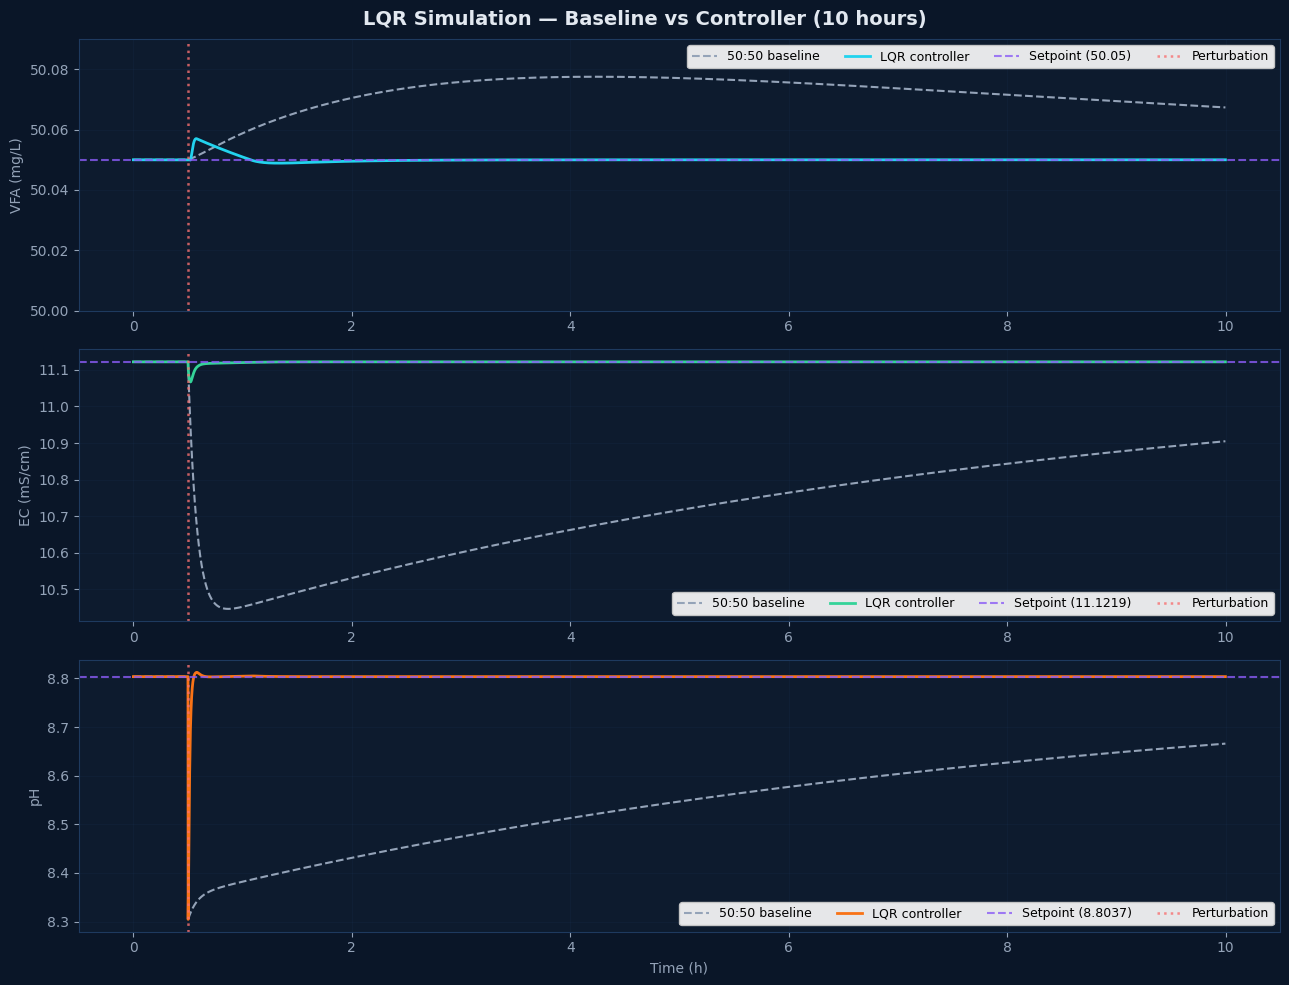

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), facecolor='#0a1628')
fig.suptitle('LQR Simulation — Baseline vs Controller (10 hours)',
             color='#e2e8f0', fontsize=14, fontweight='700')

cfg = [
    (VFA_lqr, VFA_base, x_sp[0], 'VFA (mg/L)', '#22d3ee', (50.00, 50.09)),
    (EC_lqr,  EC_base,  x_sp[1], 'EC (mS/cm)', '#34d399', None),
    (pH_lqr,  pH_base,  x_sp[2], 'pH',         '#f97316', None),
]
for ax, (lqr, base, sp, ylabel, col, ylim) in zip(axes, cfg):
    ax.set_facecolor('#0d1b2e')
    ax.plot(t_hours, base, color='#94a3b8', lw=1.5, ls='--', label='50:50 baseline')
    ax.plot(t_hours, lqr,  color=col,       lw=2,             label='LQR controller')
    ax.axhline(sp, color='#8b5cf6', ls='--', lw=1.5, alpha=0.8, label=f'Setpoint ({sp})')
    ax.axvline(t_perturb*DT/3600, color='#f87171', ls=':', lw=1.8, alpha=0.8, label='Perturbation')
    if ylim: ax.set_ylim(ylim)
    ax.set_ylabel(ylabel, color='#94a3b8', fontsize=10)
    ax.tick_params(colors='#94a3b8')
    ax.grid(True, alpha=0.15, color='#1e3a5f')
    ax.legend(fontsize=9, framealpha=0.9, ncol=4)
    for s in ax.spines.values(): s.set_color('#1e3a5f')
axes[-1].set_xlabel('Time (h)', color='#94a3b8', fontsize=10)
plt.tight_layout()
plt.show()

## 12. Flow Rate & Ratio

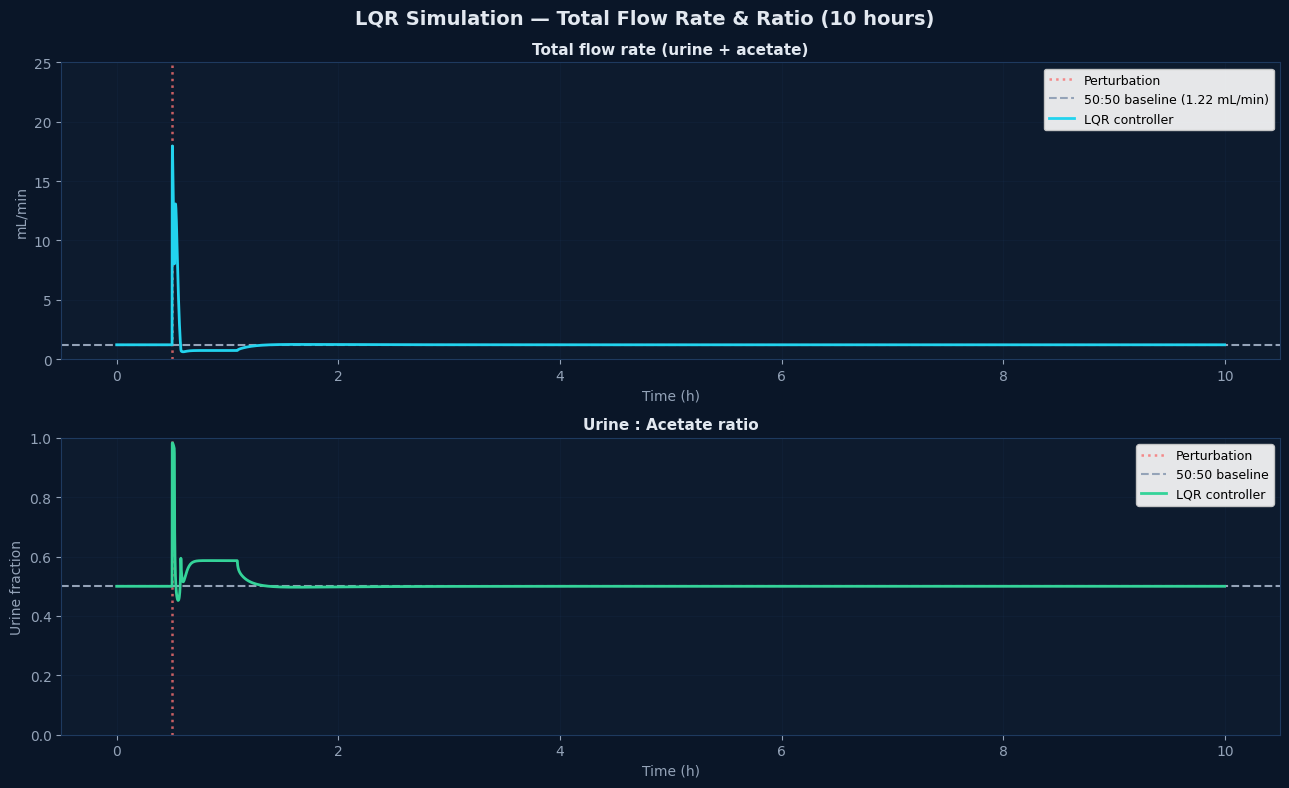

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), facecolor='#0a1628')
fig.suptitle('LQR Simulation — Total Flow Rate & Ratio (10 hours)',
             color='#e2e8f0', fontsize=14, fontweight='700')

for ax in (ax1, ax2):
    ax.set_facecolor('#0d1b2e')
    ax.tick_params(colors='#94a3b8')
    ax.grid(True, alpha=0.15, color='#1e3a5f')
    ax.axvline(t_perturb*DT/3600, color='#f87171', ls=':', lw=1.8, alpha=0.8, label='Perturbation')
    for s in ax.spines.values(): s.set_color('#1e3a5f')

ax1.axhline(total_base, color='#94a3b8', lw=1.5, ls='--',
            label=f'50:50 baseline ({total_base:.2f} mL/min)')
ax1.plot(t_hours, total_lqr, color='#22d3ee', lw=2, label='LQR controller')
ax1.set_ylim(0, 25)
ax1.set_title('Total flow rate (urine + acetate)', color='#e2e8f0', fontsize=11, fontweight='600')
ax1.set_ylabel('mL/min', color='#94a3b8', fontsize=10)
ax1.set_xlabel('Time (h)', color='#94a3b8', fontsize=10)
ax1.legend(fontsize=9, framealpha=0.9)

ax2.axhline(0.5, color='#94a3b8', lw=1.5, ls='--', label='50:50 baseline')
ax2.plot(t_hours, ratio_lqr, color='#34d399', lw=2, label='LQR controller')
ax2.set_ylim(0, 1)
ax2.set_title('Urine : Acetate ratio', color='#e2e8f0', fontsize=11, fontweight='600')
ax2.set_ylabel('Urine fraction', color='#94a3b8', fontsize=10)
ax2.set_xlabel('Time (h)', color='#94a3b8', fontsize=10)
ax2.legend(fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

## 13. Matrix Visualisations

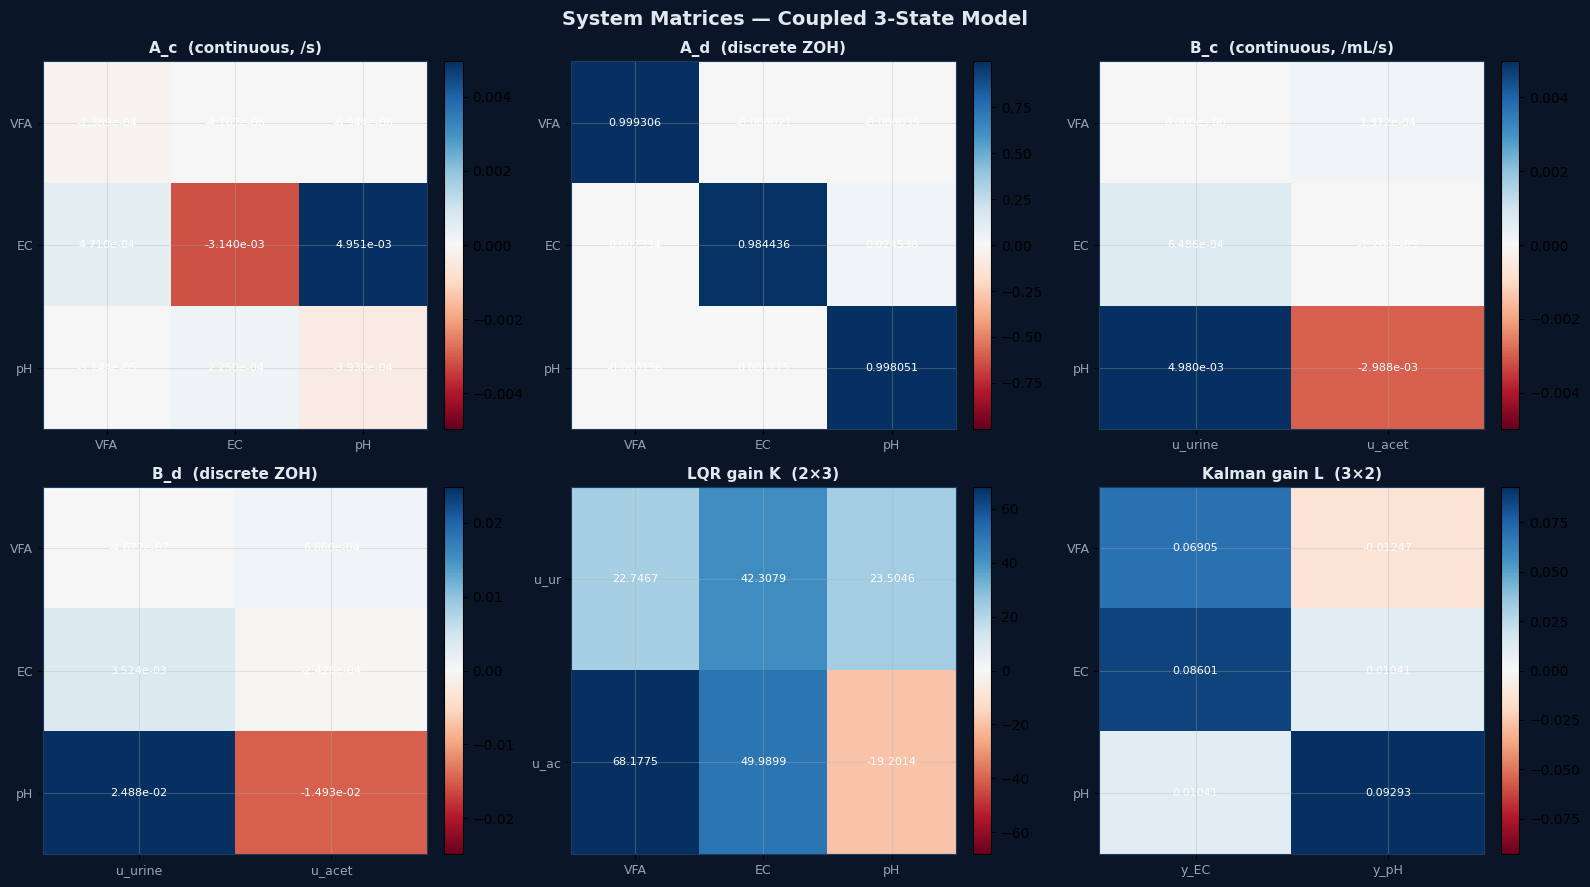

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), facecolor='#0a1628')
fig.suptitle('System Matrices — Coupled 3-State Model', color='#e2e8f0', fontsize=14, fontweight='700')

def heatmap(ax, M, title, rlbls, clbls, fmt='.3e'):
    ax.set_facecolor('#0d1b2e')
    vmax = max(abs(M).max(), 1e-10)
    im = ax.imshow(M, cmap='RdBu', aspect='auto', vmin=-vmax, vmax=vmax)
    ax.set_title(title, color='#e2e8f0', fontsize=11, fontweight='600')
    ax.set_xticks(range(len(clbls))); ax.set_xticklabels(clbls, color='#94a3b8', fontsize=9)
    ax.set_yticks(range(len(rlbls))); ax.set_yticklabels(rlbls, color='#94a3b8', fontsize=9)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, f'{M[i,j]:{fmt}}', ha='center', va='center', color='white', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for s in ax.spines.values(): s.set_color('#1e3a5f')

st = ['VFA','EC','pH']
heatmap(axes[0,0], A_c, 'A_c  (continuous, /s)',     st, st)
heatmap(axes[0,1], A_d, 'A_d  (discrete ZOH)',        st, st, fmt='.6f')
heatmap(axes[0,2], B_c, 'B_c  (continuous, /mL/s)',   st, ['u_urine','u_acet'])
heatmap(axes[1,0], B_d, 'B_d  (discrete ZOH)',        st, ['u_urine','u_acet'])
heatmap(axes[1,1], K,   'LQR gain K  (2×3)',          ['u_ur','u_ac'], st, fmt='.4f')
heatmap(axes[1,2], L,   'Kalman gain L  (3×2)',       st, ['y_EC','y_pH'], fmt='.5f')

plt.tight_layout()
plt.show()

## 14. Performance Summary

In [14]:
eigs_ol  = np.linalg.eigvals(A_d)
eigs_cl  = np.linalg.eigvals(A_d - B_d @ K)
eigs_obs = np.linalg.eigvals(A_d - L @ C_d)

print("="*60)
print("  SYSTEM SUMMARY")
print("="*60)
print(f"\nStates : [VFA, EC, pH]  (H1, H2 removed)")
print(f"Inputs : [u_urine, u_acetate]  (phosphoric not controlled)")
print(f"Outputs: [EC, pH]  (VFA unmeasured, observer estimated)")

print("\nSetpoints:")
print(f"  VFA = {x_sp[0]} mg/L")
print(f"  EC  = {x_sp[1]} mS/cm")
print(f"  pH  = {x_sp[2]}")

print("\nB matrix sources:")
print("  EC row  — dedicated EC step-response ID (image 2)")
print("  pH row  — 5-state identification (image 1)")
print("  VFA row — urine=0 (fully fermented), acetate from prior ID")

print("\nPump bounds (total flow):")
print(f"  Lower: {TOTAL_LB/DT*60:.3f} mL/min  (HRT=12h)")
print(f"  Upper: {TOTAL_UB/DT*60:.1f} mL/min  (0.730 mL/s per pump max)")

print("\nStability:")
print(f"  Open-loop  : {'STABLE' if np.all(np.abs(eigs_ol)  < 1) else 'UNSTABLE'}")
print(f"  Closed-loop: {'STABLE' if np.all(np.abs(eigs_cl)  < 1) else 'UNSTABLE'}")
print(f"  Observer   : {'STABLE' if np.all(np.abs(eigs_obs) < 1) else 'UNSTABLE'}")

print("\nSimulation (10h, pH −0.5 perturbation at 30 min):")
print(f"  VFA drift  : {VFA_lqr[-1]-VFA_lqr[0]:+.6f} mg/L")
print(f"  EC  error  : {abs(EC_lqr[-1]-x_sp[1]):.6f} mS/cm")
print(f"  pH  error  : {abs(pH_lqr[-1]-x_sp[2]):.6f}")
print("="*60)

  SYSTEM SUMMARY

States : [VFA, EC, pH]  (H1, H2 removed)
Inputs : [u_urine, u_acetate]  (phosphoric not controlled)
Outputs: [EC, pH]  (VFA unmeasured, observer estimated)

Setpoints:
  VFA = 50.05 mg/L
  EC  = 11.1219 mS/cm
  pH  = 8.8037

B matrix sources:
  EC row  — dedicated EC step-response ID (image 2)
  pH row  — 5-state identification (image 1)
  VFA row — urine=0 (fully fermented), acetate from prior ID

Pump bounds (total flow):
  Lower: 0.608 mL/min  (HRT=12h)
  Upper: 87.6 mL/min  (87.6 mL/min max)

Stability:
  Open-loop  : STABLE
  Closed-loop: STABLE
  Observer   : STABLE

Simulation (10h, pH −0.5 perturbation at 30 min):
  VFA drift  : -0.000000 mg/L
  EC  error  : 0.000000 mS/cm
  pH  error  : 0.000000
